# OBB wing detector: labels, dataset and online augmentation

Stage 1 of the oriented-box detector. Design: `docs/superpowers/specs/2026-10-07-obb-dataset-augmentation-design.md`.

1. **Labels**: the oriented box computed from the 19 landmarks (PCA recipe), and how stable it is.
2. **One wing, step by step**: flip, rotation, scale and placement, photometric steps.
3. **Training samples**: what the model will see, and that the rotation angles are spread evenly over -180...180 degrees.
4. **Real batch**: the boxes handed to the Ultralytics loss are exactly the ones we drew.
5. **Multi-wing compositions**.
6. **Frozen validation and test sets**.

Before running: `uv run python -m wings.detection.obb_dataset build` writes `data/processed/detection-obb/labels.csv`
and the image lists; for section 6 also `uv run python -m wings.detection.obb_dataset freeze`.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import stats
from torch.utils.data import DataLoader
from ultralytics.utils import ops

from wings.config import RAW_DATA_DIR
from wings.detection.obb_augment import AugConfig, WingOBBDataset, apply_photometric, load_item, plan_placement, warp_image
from wings.detection.obb_dataset import DEFAULT_MEAN_SHAPE, DEFAULT_OUT_DIR
from wings.detection.obb_labels import CORNER_COLUMNS, obb_from_landmarks, points_inside_box, principal_axis

OUT_DIR = DEFAULT_OUT_DIR
RAW_DIR = RAW_DATA_DIR
MEAN_SHAPE_PATH = DEFAULT_MEAN_SHAPE

table = pd.read_csv(OUT_DIR / "labels.csv")
by_file = table.set_index("file")
cfg = AugConfig()
print(f"{len(table)} wings, splits: {table['split'].value_counts().to_dict()}")

_coords = {}


def landmarks_of(file: str, frame: str = "image") -> np.ndarray:
    """The 19 landmarks of a raw image. frame="image": origin top-left, y down; frame="csv": as in the CSV, y up."""
    country, name = file.split("-wing-images/")
    if country not in _coords:
        _coords[country] = pd.read_csv(RAW_DIR / f"{country}-raw-coordinates.csv").set_index("file")
    values = _coords[country].loc[name].to_numpy(np.float64)
    if frame == "csv":
        return np.column_stack([values[0::2], values[1::2]])
    return np.column_stack([values[0::2], int(by_file.loc[file, "img_h"]) - values[1::2] - 1])


def corners_of(row) -> np.ndarray:
    return row[CORNER_COLUMNS].to_numpy(np.float64).reshape(4, 2)


def draw_polygons(ax, polygons, color="lime", lw=2):
    for polygon in polygons:
        closed = np.vstack([polygon, polygon[:1]])
        ax.plot(closed[:, 0], closed[:, 1], color=color, lw=lw)


def show(ax, image_bgr, title=""):
    ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=9)
    ax.axis("off")


def vertex_distance(a: np.ndarray, b: np.ndarray) -> float:
    d = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
    return float(max(d.min(axis=1).max(), d.min(axis=0).max()))

2026-10-08 09:38:05.037 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-10-08 09:38:05.957 | INFO     | wings.config:<module>:66 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


21722 wings, splits: {'train': 17401, 'val': 2197, 'test': 2124}


## 1. Labels (PCA recipe)

The box axis is the direction of the largest spread of the 19 landmarks; the sides span the extreme projections,
enlarged by the same margins as the old axis-aligned labels (x 1.2 along the axis, 1.4 across), and then by 10% of the box width on the lower side only (the lobe of the wing sticks out there).

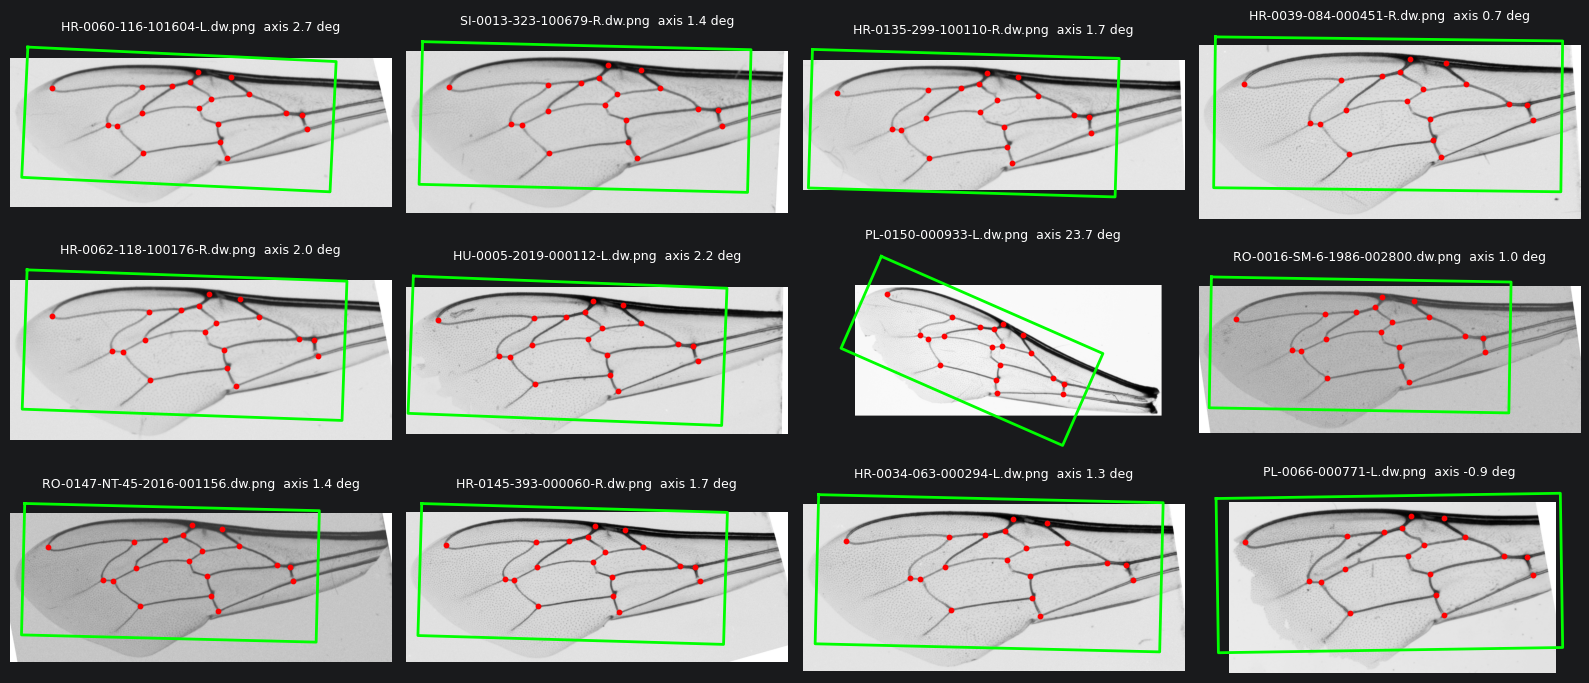

In [2]:
sample_rows = table.sample(12, random_state=0)
fig, axes = plt.subplots(3, 4, figsize=(16, 7))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    show(ax, cv2.imread(str(RAW_DIR / row["file"])), f"{Path(row['file']).name}  axis {row['theta_deg']:.1f} deg")
    points = landmarks_of(row["file"])
    ax.scatter(points[:, 0], points[:, 1], s=10, c="red")
    draw_polygons(ax, [corners_of(row)])
plt.tight_layout()
plt.show()

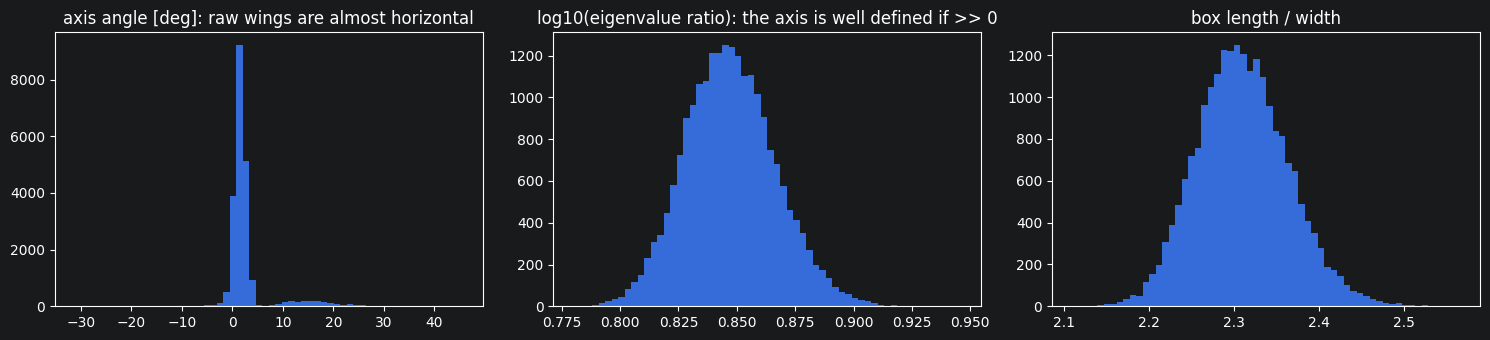

axis angle: mean 2.72, std 4.60, min -31.3, max 45.8
rows with an ill-defined axis (eig_ratio < 1.5): 0
wings with a landmark outside their box: 0 of 3000 checked


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(table["theta_deg"], bins=60)
axes[0].set(title="axis angle [deg]: raw wings are almost horizontal")
axes[1].hist(np.log10(table["eig_ratio"]), bins=60)
axes[1].set(title="log10(eigenvalue ratio): the axis is well defined if >> 0")
axes[2].hist(table["length"] / table["width"], bins=60)
axes[2].set(title="box length / width")
plt.tight_layout()
plt.show()
print(f"axis angle: mean {table['theta_deg'].mean():.2f}, std {table['theta_deg'].std():.2f}, min {table['theta_deg'].min():.1f}, max {table['theta_deg'].max():.1f}")
print("rows with an ill-defined axis (eig_ratio < 1.5):", int((table["eig_ratio"] < 1.5).sum()))

checked = table.sample(min(3000, len(table)), random_state=1)
outside = [row["file"] for _, row in checked.iterrows() if not points_inside_box(corners_of(row), landmarks_of(row["file"]), tol=0.01)]
print(f"wings with a landmark outside their box: {len(outside)} of {len(checked)} checked")

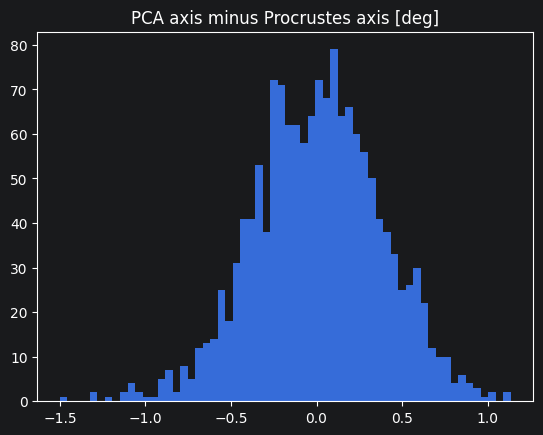

median 0.02, 5-95%: -0.59 .. 0.61, largest |difference| 1.50


In [4]:
from wings.gpa import center_shape, normalize_shape, procrustes_align

mean_shape = torch.load(MEAN_SHAPE_PATH, weights_only=False).float()
mean_unit = normalize_shape(center_shape(mean_shape))
mean_axis, _ = principal_axis(mean_shape.numpy())


def procrustes_axis_deg(points_csv: np.ndarray) -> float:
    """Axis angle implied by the Procrustes alignment to the mean shape (CSV frame, y up), modulo 180 degrees."""
    unit = normalize_shape(center_shape(torch.tensor(points_csv, dtype=torch.float32)))
    rotation = procrustes_align(unit, mean_unit, only_matrix=True, allow_reflection=True)
    direction = mean_axis @ rotation.numpy().T  # unit @ R ~ mean, so the mean axis seen from the wing is mean_axis @ R.T
    return float(np.degrees(np.arctan2(direction[1], direction[0])) % 180.0)


differences = []
for _, row in table.sample(min(1500, len(table)), random_state=2).iterrows():
    points_csv = landmarks_of(row["file"], frame="csv")
    pca = obb_from_landmarks(points_csv).theta_deg % 180.0
    differences.append((pca - procrustes_axis_deg(points_csv) + 90.0) % 180.0 - 90.0)
differences = np.array(differences)
plt.hist(differences, bins=60)
plt.title("PCA axis minus Procrustes axis [deg]")
plt.show()
print(f"median {np.median(differences):.2f}, 5-95%: {np.percentile(differences, 5):.2f} .. {np.percentile(differences, 95):.2f}, largest |difference| {np.abs(differences).max():.2f}")

In [5]:
jitter_rng = np.random.default_rng(3)
spreads = []
for _, row in table.sample(min(300, len(table)), random_state=3).iterrows():
    points = landmarks_of(row["file"])
    angles = [obb_from_landmarks(points + jitter_rng.normal(0, 1.0, points.shape)).theta_deg for _ in range(20)]
    spreads.append(np.std(angles))
print(f"axis angle std under 1 px landmark jitter [deg]: median {np.median(spreads):.3f}, 95th percentile {np.percentile(spreads, 95):.3f}")

axis angle std under 1 px landmark jitter [deg]: median 0.111, 95th percentile 0.142


## 2. One wing, step by step

Flip, rotation about the box centre, scale and position are ONE affine warp, so the corners are transformed exactly.
Areas outside the source image get the image's own background colour (third panel). Gray 114, the Ultralytics default
(fourth panel), would make the rotated corners an easy cue that never appears on real photos.

flip=True  angle=-0.3 deg  scale=0.633  background (BGR)=(209, 209, 209)


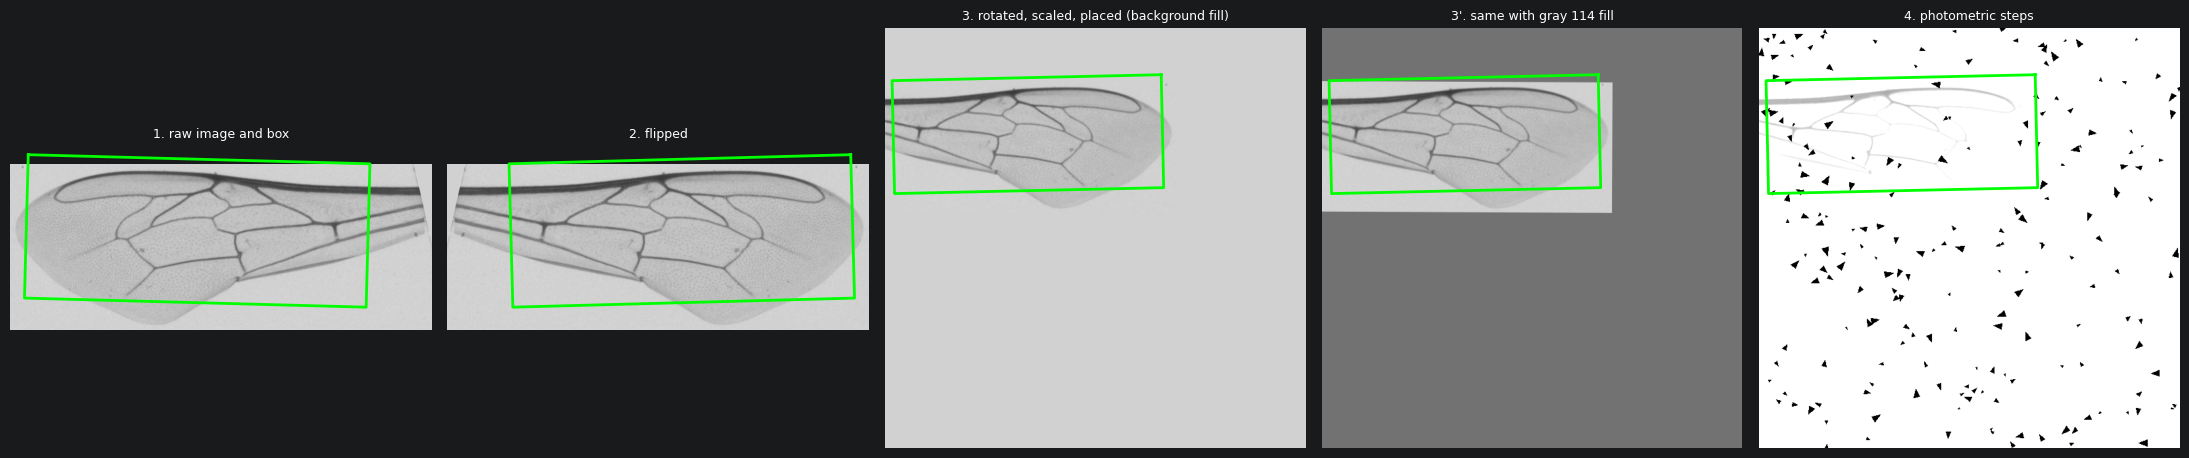

In [6]:
row = table[table["split"] == "train"].sample(1, random_state=5).iloc[0]
item = load_item(RAW_DIR / row["file"], row)
step_rng = np.random.default_rng(11)
placement = plan_placement(item.corners, item.image.shape[1], (0, 0, cfg.imgsz, cfg.imgsz), step_rng, cfg)
flipped = cv2.flip(item.image, 1)
flipped_corners = item.corners * [-1, 1] + [item.image.shape[1] - 1, 0]
final = warp_image(item.image, placement.matrix, cfg.imgsz, item.background)
gray_fill = warp_image(item.image, placement.matrix, cfg.imgsz, (114, 114, 114))
photometric = apply_photometric(final, step_rng, cfg)
print(f"flip={placement.flip}  angle={placement.angle_deg:.1f} deg  scale={placement.scale:.3f}  background (BGR)={item.background}")

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
show(axes[0], item.image, "1. raw image and box")
draw_polygons(axes[0], [item.corners])
show(axes[1], flipped if placement.flip else item.image, "2. flipped" if placement.flip else "2. not flipped in this draw")
draw_polygons(axes[1], [flipped_corners if placement.flip else item.corners])
show(axes[2], final, "3. rotated, scaled, placed (background fill)")
draw_polygons(axes[2], [placement.corners])
show(axes[3], gray_fill, "3'. same with gray 114 fill")
draw_polygons(axes[3], [placement.corners])
show(axes[4], photometric, "4. photometric steps")
draw_polygons(axes[4], [placement.corners])
plt.tight_layout()
plt.show()

## 3. Training samples

Single-wing samples only (`p_multi=0`). Green: the box that goes into the label.

train: Fast image access  (ping: 0.10.1 ms, read: 453.869.0 MB/s, size: 120.9 KB)


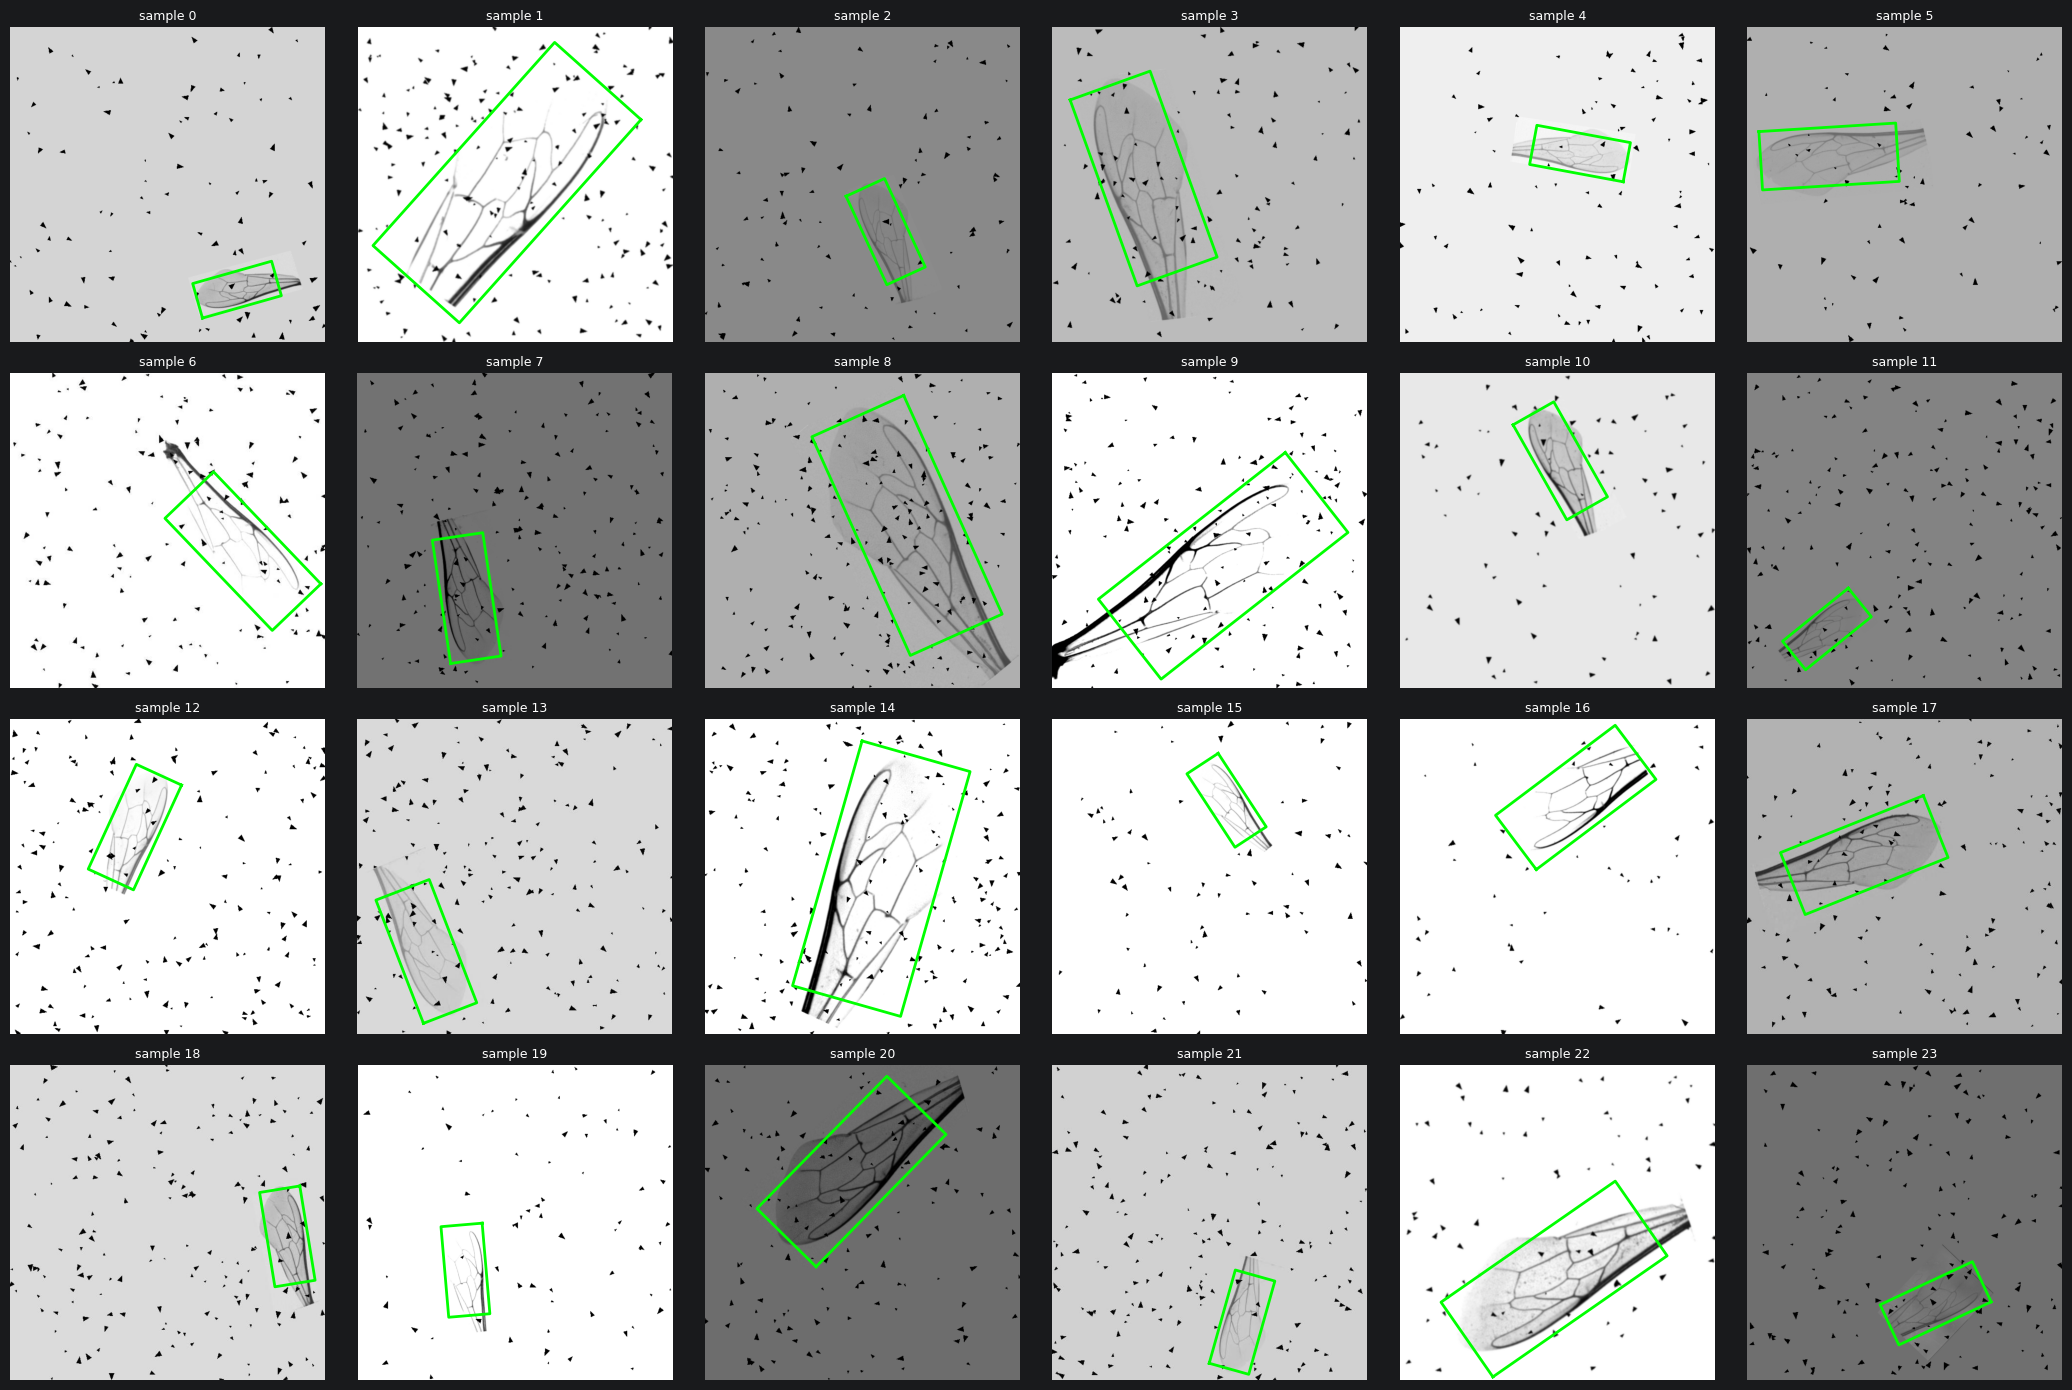

In [7]:
single = WingOBBDataset(OUT_DIR / "labels.csv", "train", OUT_DIR / "train.txt", raw_dir=RAW_DIR, cfg=AugConfig(p_multi=0.0))
fig, axes = plt.subplots(4, 6, figsize=(21, 14))
for k, ax in enumerate(axes.flat):
    label = single.label_for(int(np.random.default_rng(k).integers(0, len(single))), seed=k)
    show(ax, label["img"], f"sample {k}")
    draw_polygons(ax, label["instances"].segments)
plt.tight_layout()
plt.show()

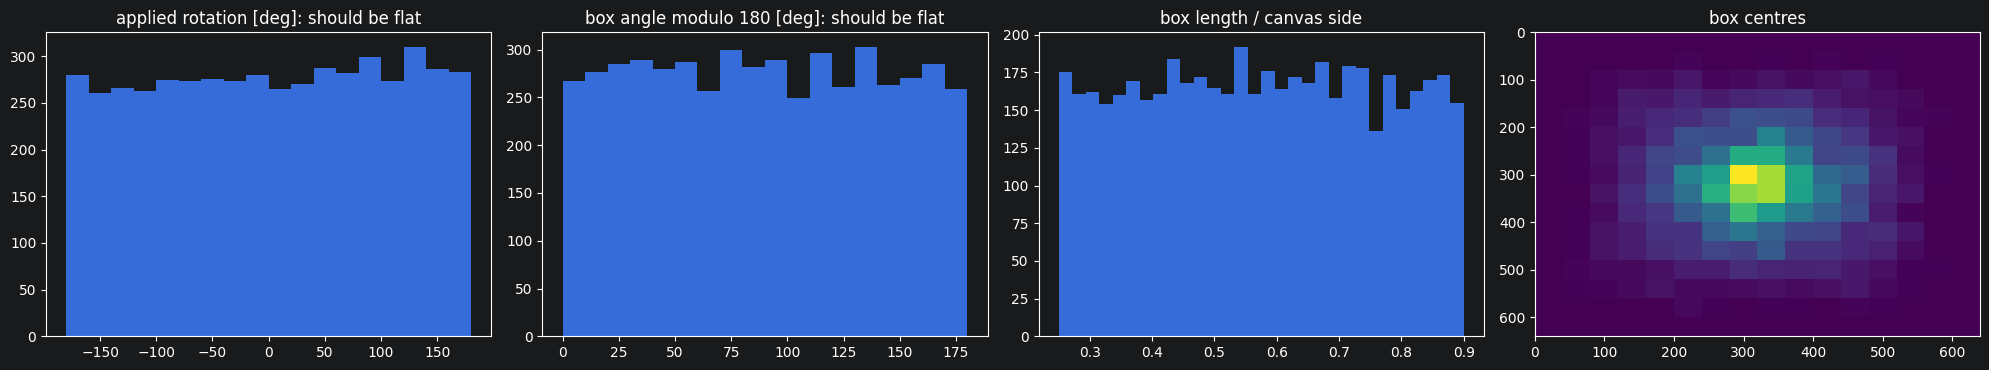

Kolmogorov-Smirnov p-values for uniformity: rotation 0.142, box angle 0.784 (uniform is rejected below 0.01)


In [8]:
train_rows = table[table["split"] == "train"]
draw_rng = np.random.default_rng(21)
angles, box_angles, fractions, centres = [], [], [], []
for _ in range(5000):
    row = train_rows.iloc[int(draw_rng.integers(0, len(train_rows)))]
    placement = plan_placement(corners_of(row), int(row["img_w"]), (0, 0, cfg.imgsz, cfg.imgsz), draw_rng, cfg)
    edge = placement.corners[1] - placement.corners[0]
    angles.append(placement.angle_deg)
    box_angles.append(np.degrees(np.arctan2(edge[1], edge[0])) % 180.0)
    fractions.append(np.linalg.norm(edge) / cfg.imgsz)
    centres.append(placement.corners.mean(axis=0))
centres = np.array(centres)

fig, axes = plt.subplots(1, 4, figsize=(20, 3.8))
axes[0].hist(angles, bins=18, range=(-180, 180))
axes[0].set(title="applied rotation [deg]: should be flat")
axes[1].hist(box_angles, bins=18, range=(0, 180))
axes[1].set(title="box angle modulo 180 [deg]: should be flat")
axes[2].hist(fractions, bins=30)
axes[2].set(title="box length / canvas side")
axes[3].hist2d(centres[:, 0], centres[:, 1], bins=16, range=[[0, cfg.imgsz], [0, cfg.imgsz]])
axes[3].invert_yaxis()
axes[3].set(title="box centres")
plt.tight_layout()
plt.show()
p_rotation = stats.kstest((np.array(angles) + 180) / 360, "uniform").pvalue
p_box = stats.kstest(np.array(box_angles) / 180, "uniform").pvalue
print(f"Kolmogorov-Smirnov p-values for uniformity: rotation {p_rotation:.3f}, box angle {p_box:.3f} (uniform is rejected below 0.01)")
assert p_rotation > 0.01 and p_box > 0.01

## 4. Real batch

A `DataLoader` with the stock Ultralytics `collate_fn`. Yellow: boxes rebuilt from the `xywhr` tensor that enters the loss.
Below, the same boxes are compared numerically with our own corners.

{'batch_idx': (8,), 'bboxes': (8, 5), 'cls': (8, 1), 'im_file': 'tuple', 'img': (8, 3, 640, 640), 'ori_shape': 'tuple', 'ratio_pad': 'tuple', 'resized_shape': 'tuple'}


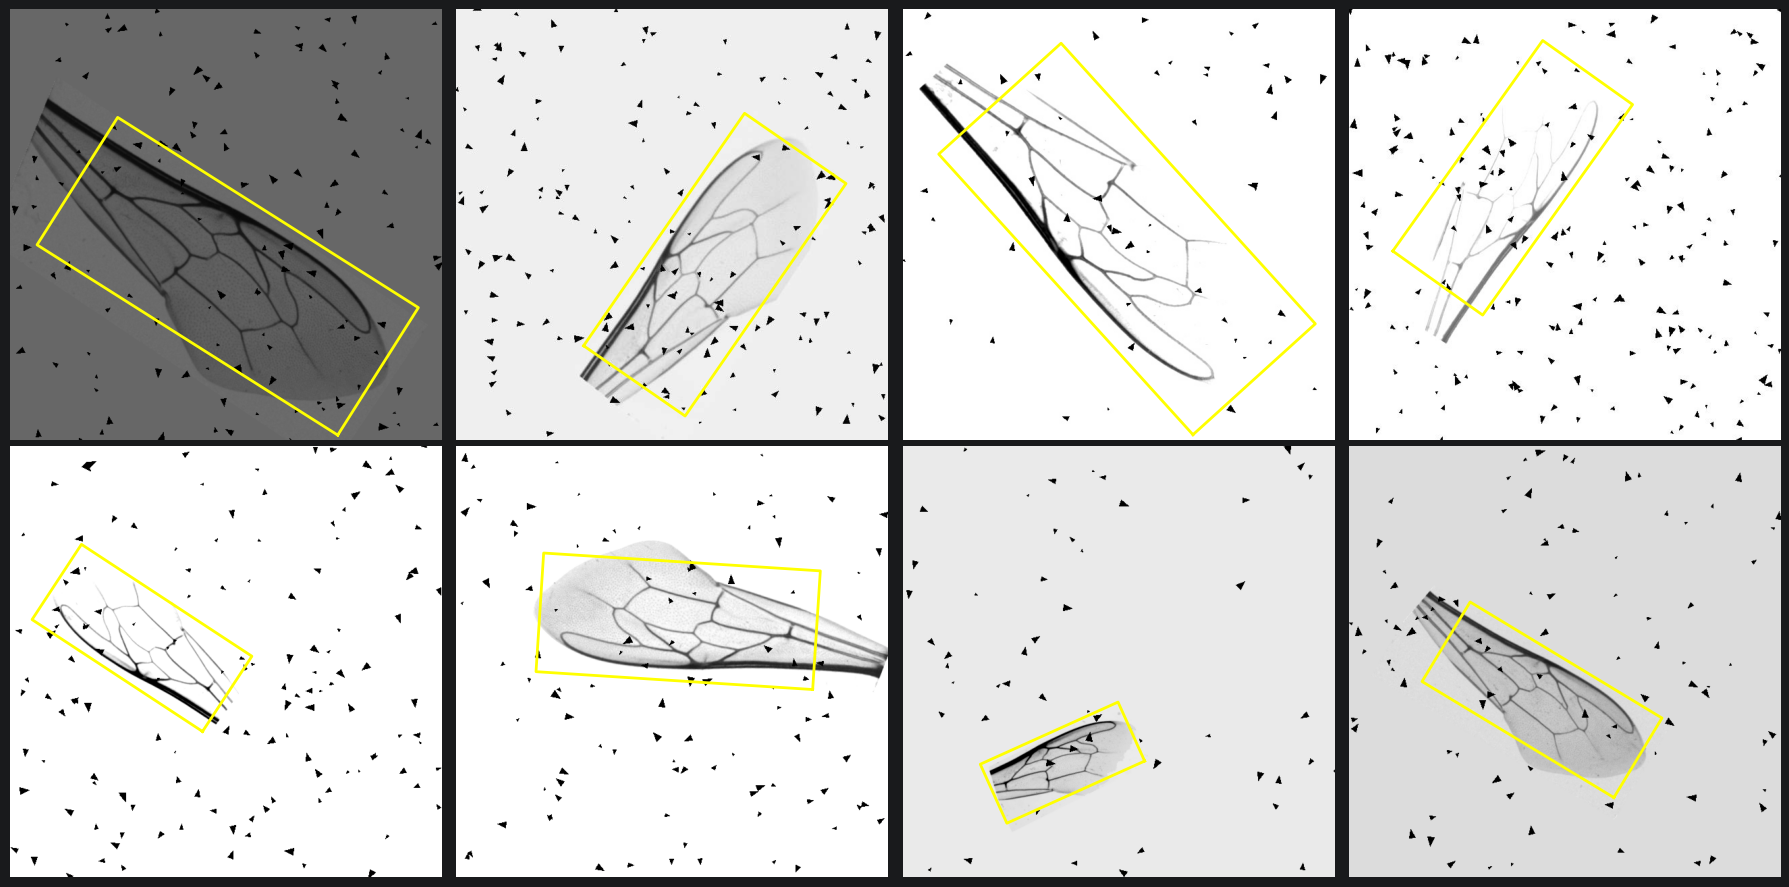

largest corner difference between our boxes and the tensor given to the loss: 0.0002 px


In [9]:
loader = DataLoader(single, batch_size=8, shuffle=True, num_workers=0, collate_fn=WingOBBDataset.collate_fn)
batch = next(iter(loader))
print({key: tuple(value.shape) if hasattr(value, "shape") else type(value).__name__ for key, value in batch.items()})
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    image = batch["img"][i].permute(1, 2, 0).numpy()  # RGB, uint8
    ax.imshow(image)
    ax.axis("off")
    boxes = batch["bboxes"][batch["batch_idx"] == i].clone()
    boxes[:, [0, 2]] *= image.shape[1]
    boxes[:, [1, 3]] *= image.shape[0]
    draw_polygons(ax, ops.xywhr2xyxyxyxy(boxes).numpy(), color="yellow")
plt.tight_layout()
plt.show()

worst = 0.0
for i in range(64):
    label = single.label_for(i % len(single), seed=i)
    ours = label["instances"].segments.copy()
    formatted = single.transforms(label)
    rboxes = formatted["bboxes"].clone()
    rboxes[:, [0, 2]] *= cfg.imgsz
    rboxes[:, [1, 3]] *= cfg.imgsz
    theirs = ops.xywhr2xyxyxyxy(rboxes).numpy()
    for polygon in ours:
        worst = max(worst, min(vertex_distance(polygon, other) for other in theirs))
print(f"largest corner difference between our boxes and the tensor given to the loss: {worst:.4f} px")
assert worst < 0.5

## 5. Multi-wing compositions

2-4 wings on one canvas, each with its own flip, rotation and scale, in separate cells of a grid, so the boxes cannot overlap.

train: Fast image access  (ping: 0.10.0 ms, read: 716.8290.0 MB/s, size: 131.6 KB)


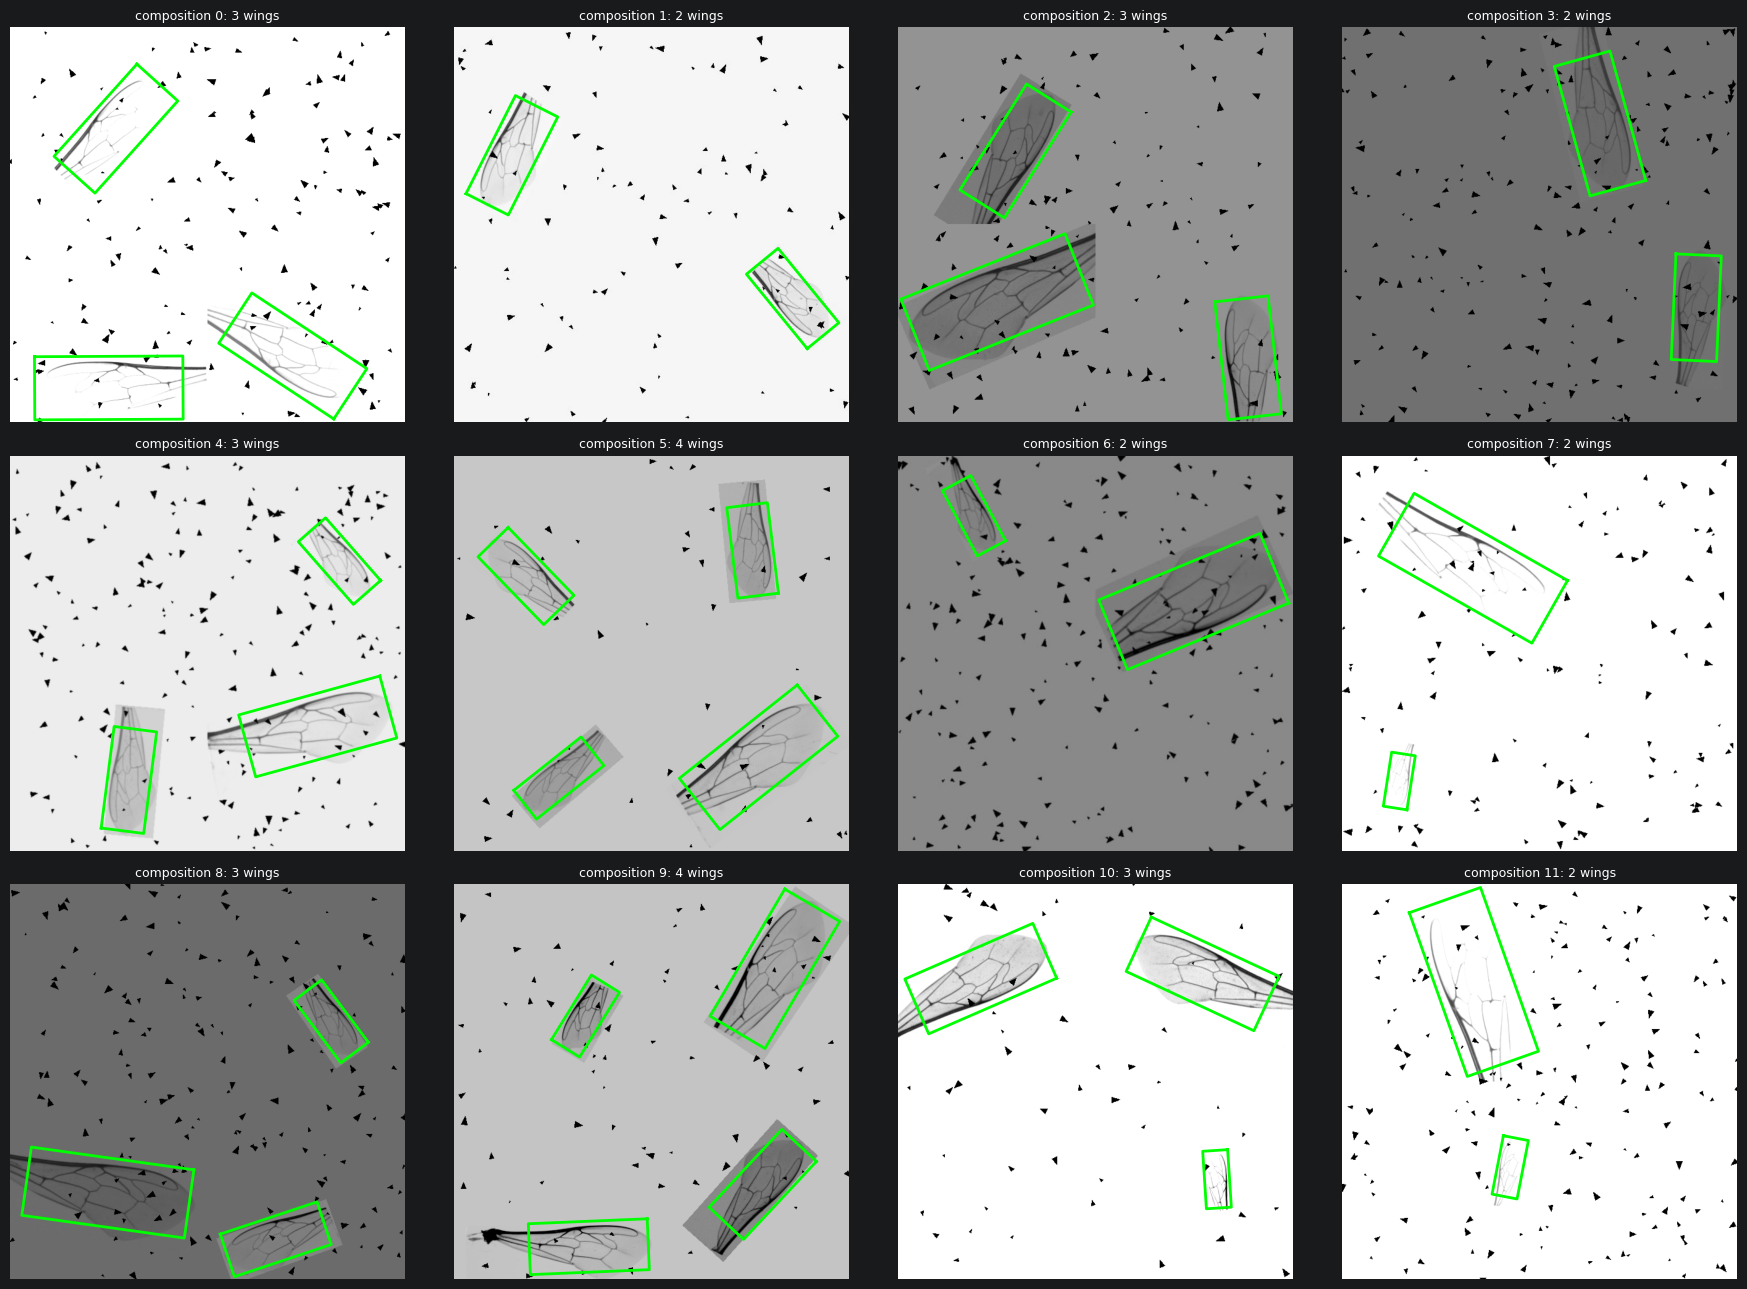

share of compositions with k wings: {2: 0.503, 3: 0.253, 4: 0.244}
300 compositions: 0 overlapping pairs, 0 boxes outside the canvas


In [10]:
from wings.detection.obb_augment import choose_k

multi = WingOBBDataset(OUT_DIR / "labels.csv", "train", OUT_DIR / "train.txt", raw_dir=RAW_DIR, cfg=AugConfig(p_multi=1.0))
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for k, ax in enumerate(axes.flat):
    label = multi.label_for(int(np.random.default_rng(k).integers(0, len(multi))), seed=100 + k)
    show(ax, label["img"], f"composition {k}: {len(label['instances'].segments)} wings")
    draw_polygons(ax, label["instances"].segments)
plt.tight_layout()
plt.show()

ks = pd.Series([choose_k(np.random.default_rng(i)) for i in range(2000)]).value_counts(normalize=True).sort_index()
print("share of compositions with k wings:", ks.round(3).to_dict())

overlapping, outside_canvas = 0, 0
for i in range(300):
    polygons = multi.label_for(i % len(multi), seed=1000 + i)["instances"].segments
    boxes = np.concatenate([polygons.min(axis=1), polygons.max(axis=1)], axis=1)  # x0, y0, x1, y1
    outside_canvas += int(polygons.min() < 0 or polygons.max() > cfg.imgsz)
    for a in range(len(boxes)):
        for b in range(a + 1, len(boxes)):
            A, B = boxes[a], boxes[b]
            overlapping += int(not (A[2] <= B[0] or B[2] <= A[0] or A[3] <= B[1] or B[3] <= A[1]))
print(f"300 compositions: {overlapping} overlapping pairs, {outside_canvas} boxes outside the canvas")
assert overlapping == 0 and outside_canvas == 0

## 6. Frozen validation and test sets

Generated once by `uv run python -m wings.detection.obb_dataset freeze` with a fixed seed. Below: examples, and a check that
regenerating the first validation samples with the same seeds gives exactly the stored files.

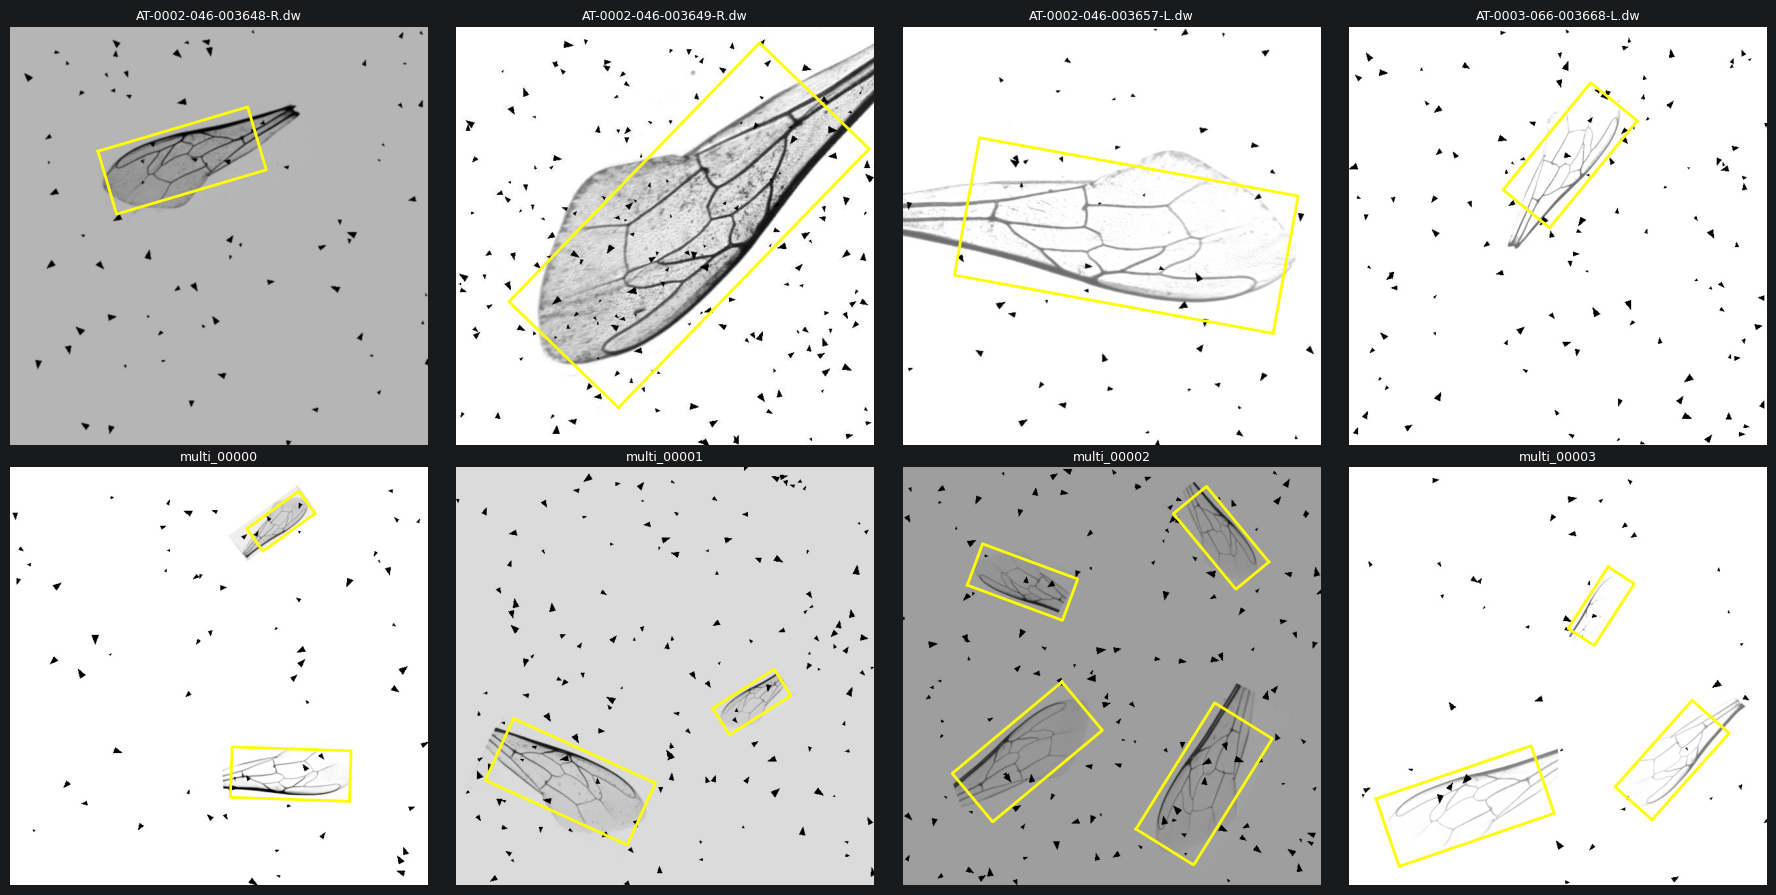

regenerated samples identical to the stored files: True [True, True, True, True, True, True, True, True, True, True]


In [11]:
from wings.detection.obb_augment import make_single_sample
from wings.detection.obb_dataset import FROZEN_JPEG_QUALITY

val_dir = OUT_DIR / "val"
if not (val_dir / "images").exists():
    print("Frozen sets not found. Run: uv run python -m wings.detection.obb_dataset freeze")
else:
    stems = sorted(p.stem for p in (val_dir / "images").glob("*.jpg"))
    shown = [s for s in stems if not s.startswith("multi_")][:4] + [s for s in stems if s.startswith("multi_")][:4]
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    for ax, stem in zip(axes.flat, shown):
        image = cv2.imread(str(val_dir / "images" / f"{stem}.jpg"))
        show(ax, image, stem)
        for line in (val_dir / "labels" / f"{stem}.txt").read_text().strip().splitlines():
            draw_polygons(ax, [np.array(line.split()[1:], dtype=float).reshape(4, 2) * image.shape[0]], color="yellow")
    plt.tight_layout()
    plt.show()

    identical = []
    for _, row in table[table["split"] == "val"].head(10).iterrows():
        rng = np.random.default_rng([7, 1, int(row.name), 0])  # (seed, split id of val, row index, single-wing)
        regenerated = make_single_sample(load_item(RAW_DIR / row["file"], row), rng, cfg).image
        _, buffer = cv2.imencode(".jpg", regenerated, [cv2.IMWRITE_JPEG_QUALITY, FROZEN_JPEG_QUALITY])
        stored = cv2.imread(str(val_dir / "images" / f"{Path(row['file']).stem}.jpg"))
        identical.append(bool((cv2.imdecode(buffer, cv2.IMREAD_COLOR) == stored).all()))
    print("regenerated samples identical to the stored files:", all(identical), identical)
    assert all(identical)